In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_array_distribution(array, title="Data Distribution", figsize=(15, 10)):
    """
    Plot the distribution of data in a numpy array with shape (B, W, H).
    
    Parameters:
    -----------
    array : numpy.ndarray
        Input array with shape (B, W, H) where B is batch size, W is width, H is height
    title : str
        Title for the plot
    figsize : tuple
        Figure size for the plot
    """
    
    if len(array.shape) != 3:
        raise ValueError(f"Expected 3D array with shape (B, W, H), got shape {array.shape}")
    
    B, W, H = array.shape
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(f'{title} - Array Shape: {array.shape}', fontsize=16)
    
    # Flatten array for overall statistics
    flat_array = array.flatten()
    
    # Plot 1: Overall histogram
    axes[0, 0].hist(flat_array, bins=50, alpha=0.7, edgecolor='black')
    axes[0, 0].set_title('Overall Value Distribution')
    axes[0, 0].set_xlabel('Value')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Box plot per batch
    batch_data = [array[i].flatten() for i in range(B)]
    axes[0, 1].boxplot(batch_data, labels=[f'Batch {i}' for i in range(B)])
    axes[0, 1].set_title('Distribution per Batch')
    axes[0, 1].set_xlabel('Batch')
    axes[0, 1].set_ylabel('Value')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Heatmap of mean values across batches
    mean_across_batches = np.mean(array, axis=0)
    im = axes[1, 0].imshow(mean_across_batches, cmap='viridis', aspect='auto')
    axes[1, 0].set_title('Mean Values Across Batches (W x H)')
    axes[1, 0].set_xlabel('Height')
    axes[1, 0].set_ylabel('Width')
    plt.colorbar(im, ax=axes[1, 0])
    
    # Plot 4: Statistics summary
    axes[1, 1].axis('off')
    
    # Calculate statistics
    stats_text = f"""
    Array Statistics:
    
    Shape: {array.shape}
    Total elements: {array.size:,}
    
    Min value: {np.min(flat_array):.4f}
    Max value: {np.max(flat_array):.4f}
    Mean: {np.mean(flat_array):.4f}
    Std: {np.std(flat_array):.4f}
    
    Unique values: {len(np.unique(flat_array))}
    
    Value counts (top 10):
    """
    
    # Get value counts
    unique_vals, counts = np.unique(flat_array, return_counts=True)
    sorted_indices = np.argsort(counts)[::-1]
    
    for i in range(min(10, len(unique_vals))):
        idx = sorted_indices[i]
        percentage = (counts[idx] / len(flat_array)) * 100
        stats_text += f"\n  {unique_vals[idx]:.4f}: {counts[idx]:,} ({percentage:.2f}%)"
    
    # Special check for all ones
    if np.all(flat_array == 1):
        stats_text += "\n\n✓ ALL VALUES ARE 1"
    elif np.all(flat_array == 0):
        stats_text += "\n\n✓ ALL VALUES ARE 0"
    else:
        ones_count = np.sum(flat_array == 1)
        ones_percentage = (ones_count / len(flat_array)) * 100
        stats_text += f"\n\nOnes: {ones_count:,} ({ones_percentage:.2f}%)"
    
    axes[1, 1].text(0.05, 0.95, stats_text, transform=axes[1, 1].transAxes, 
                    fontsize=10, verticalalignment='top', fontfamily='monospace')
    
    plt.tight_layout()
    plt.show()
    
    return fig


In [8]:
BARLOWTWINS_PRUNED_HEATMAPS_DIR = 'BarlowTwins/Heatmap_arrays/BarlowTwins_pruned_GradCAM_heatmaps.npy'
barlowtwins_pruned_heatmaps = np.load(BARLOWTWINS_PRUNED_HEATMAPS_DIR)
DENSENET161_PRUNED_HEATMAPS_DIR = 'DenseNet-161/Heatmap_arrays/DenseNet161_pruned_GradCAM_heatmaps.npy'
densenet161_pruned_heatmaps = np.load(DENSENET161_PRUNED_HEATMAPS_DIR)

/tmp/ipykernel_649930/1308143818.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(batch_data, labels=[f'Batch {i}' for i in range(B)])


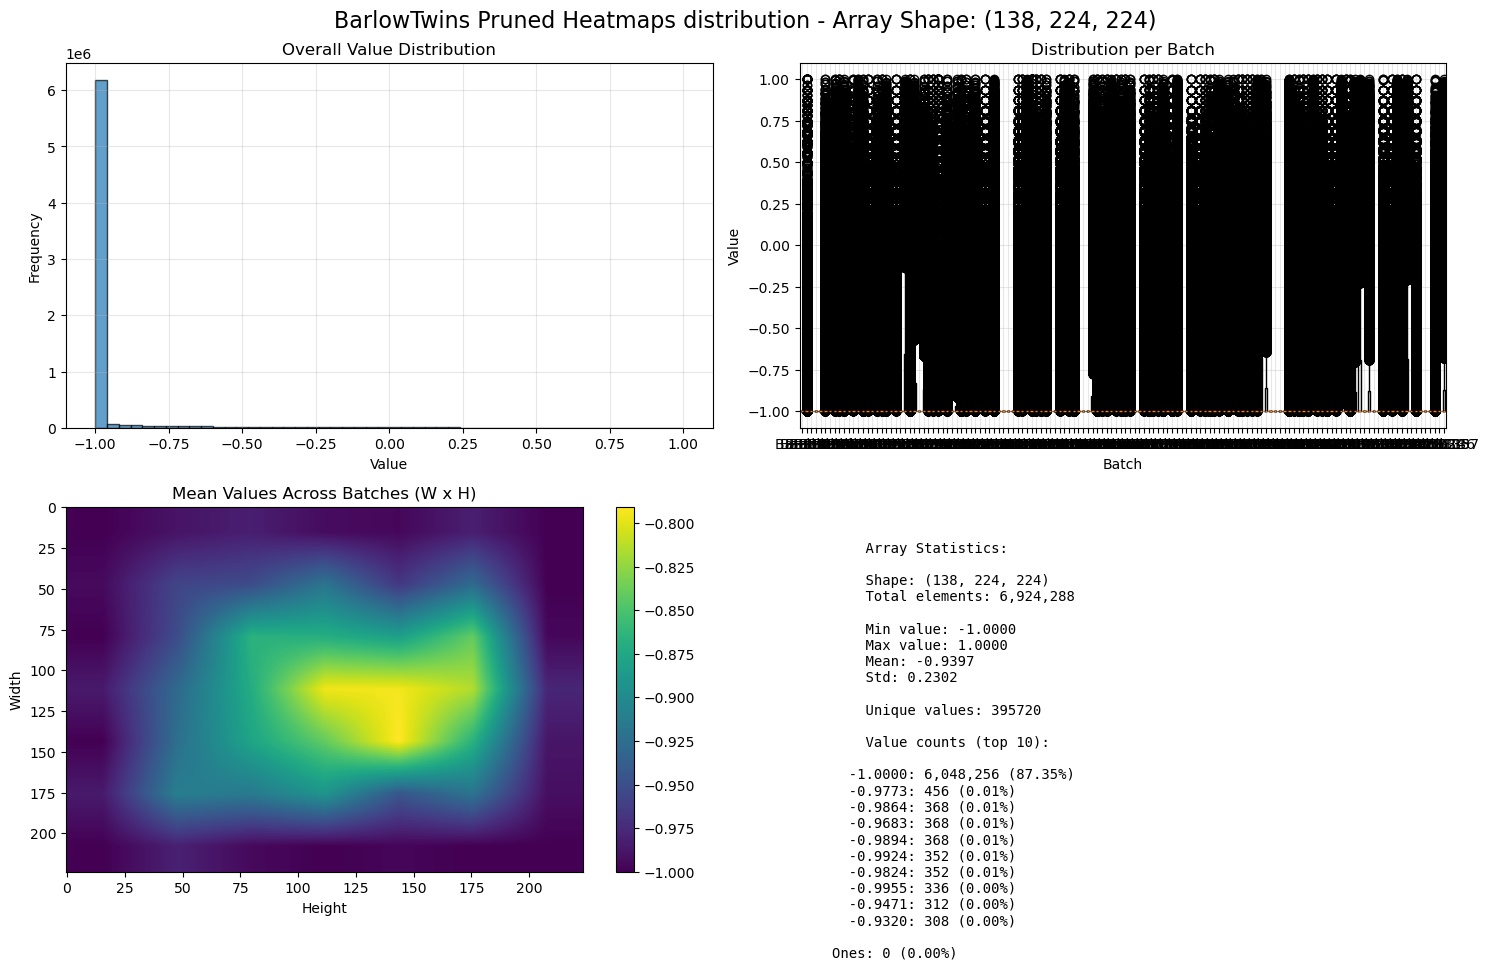

/tmp/ipykernel_649930/1308143818.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(batch_data, labels=[f'Batch {i}' for i in range(B)])


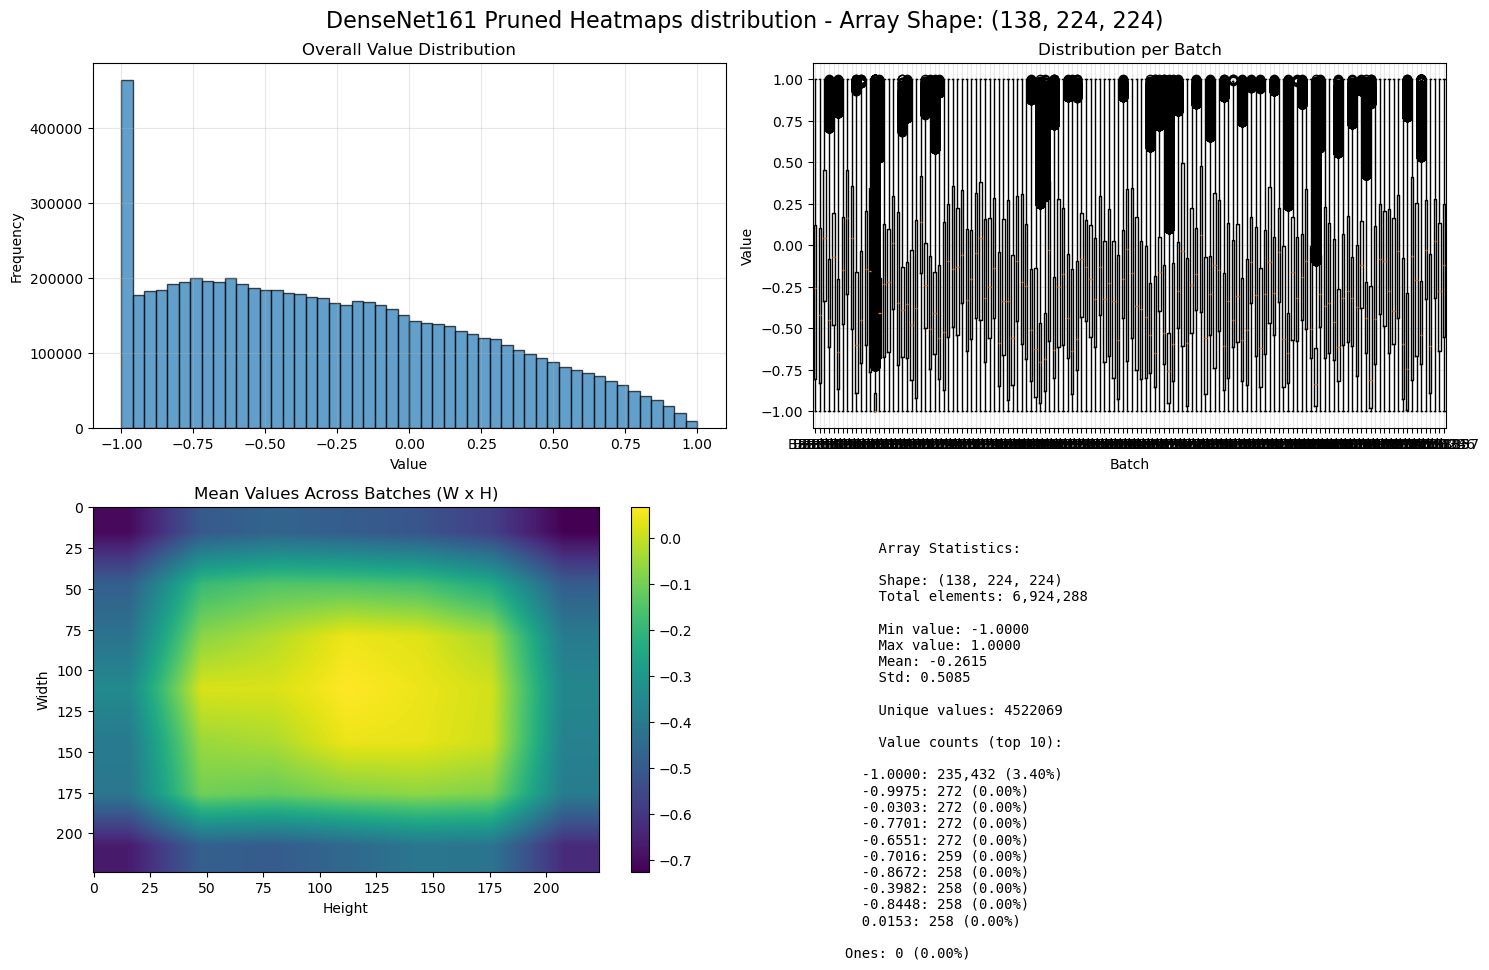

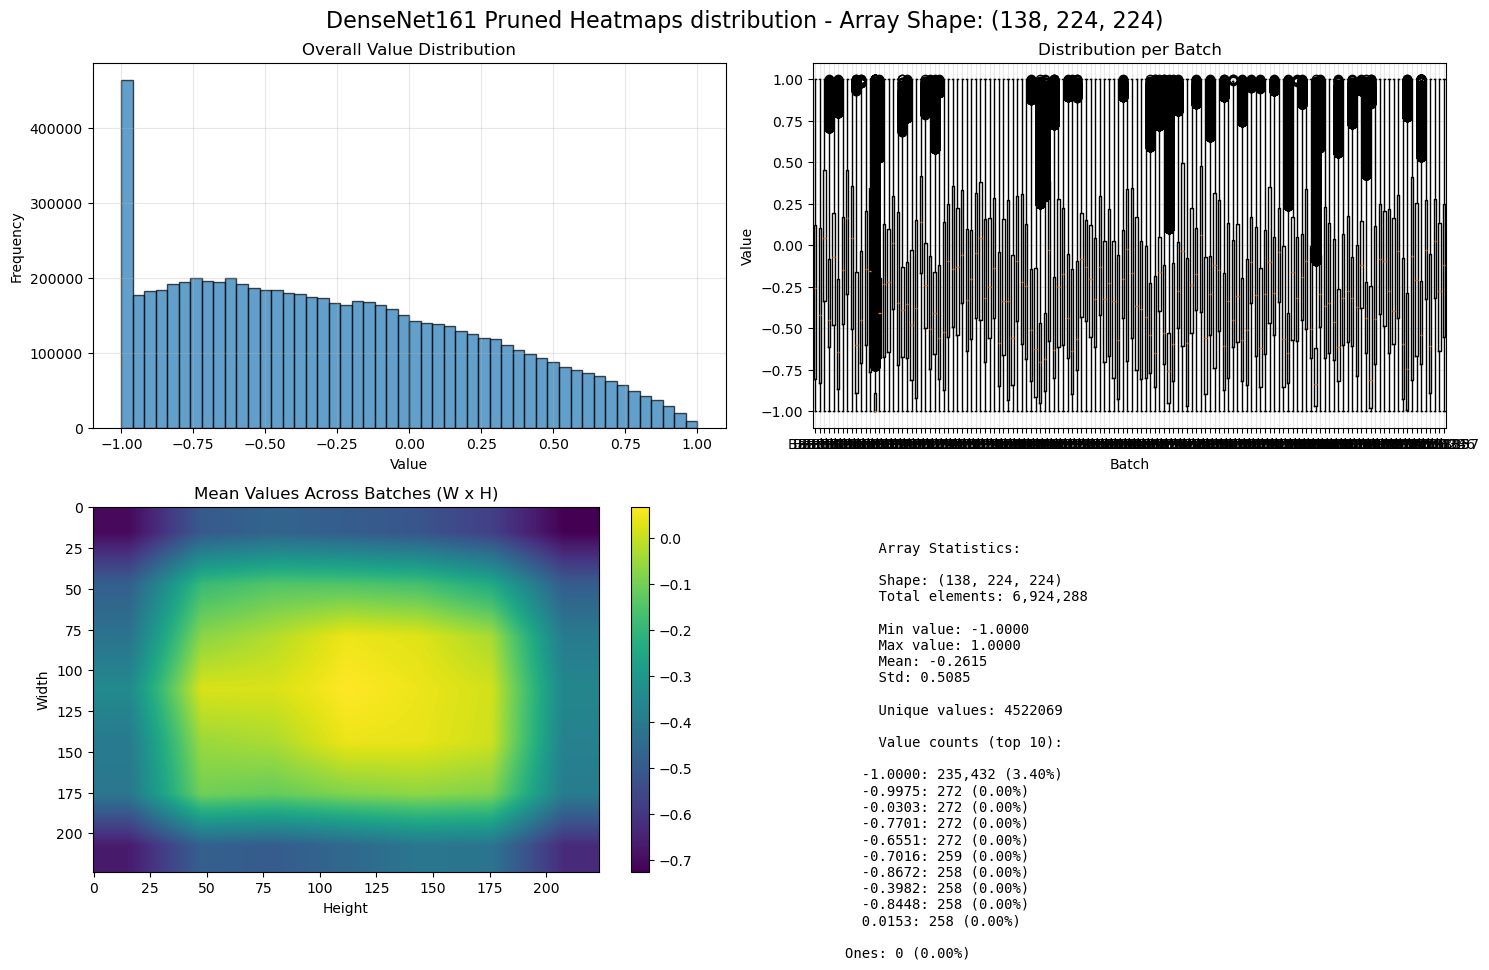

In [9]:
plot_array_distribution(barlowtwins_pruned_heatmaps, "BarlowTwins Pruned Heatmaps distribution")
plot_array_distribution(densenet161_pruned_heatmaps, "DenseNet161 Pruned Heatmaps distribution")